In [7]:
import pandas as pd 
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import gc
import os
import sys
%matplotlib inline

In [10]:
def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > -128 and c_max < 127:
                    df[col] = df[col].astype('int8')
                elif c_min > -32768 and c_max < 32767:
                    df[col] = df[col].astype('int16')
                elif c_min > -2147483648 and c_max < 2147483647:
                    df[col] = df[col].astype('int32')
            else:
                if c_min > -3.4e+38 and c_max < 3.4e+38:
                    df[col] = df[col].astype('float32')
    return df 

In [8]:
cab_rides = pd.read_csv("cab_rides.csv")
weather = pd.read_csv("weather.csv")

In [13]:
cab_data = pd.read_csv("cab_rides.csv")
cab_data = reduce_mem_usage(cab_data)
weather_data = pd.read_csv("weather.csv")
weather_data = reduce_mem_usage(weather_data)

In [15]:
cab_data.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [16]:
cab_data.columns

Index(['distance', 'cab_type', 'time_stamp', 'destination', 'source', 'price',
       'surge_multiplier', 'id', 'product_id', 'name'],
      dtype='object')

In [17]:
weather_data.columns

Index(['temp', 'location', 'clouds', 'pressure', 'rain', 'time_stamp',
       'humidity', 'wind'],
      dtype='object')

In [27]:
import datetime
cab_data['datetime'] = pd.to_datetime(cab_data['time_stamp'], unit='ms')
cab_data
weather_data['datetime'] = pd.to_datetime(weather_data['time_stamp'], unit='s')
weather_data

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind,datetime
0,42.419998,Back Bay,1.00,1012.140015,0.1228,1545003901,0.77,11.25,2018-12-16 23:45:01
1,42.430000,Beacon Hill,1.00,1012.150024,0.1846,1545003901,0.76,11.32,2018-12-16 23:45:01
2,42.500000,Boston University,1.00,1012.150024,0.1089,1545003901,0.76,11.07,2018-12-16 23:45:01
3,42.110001,Fenway,1.00,1012.130005,0.0969,1545003901,0.77,11.09,2018-12-16 23:45:01
4,43.130001,Financial District,1.00,1012.140015,0.1786,1545003901,0.75,11.49,2018-12-16 23:45:01
...,...,...,...,...,...,...,...,...,...
6271,44.720001,North Station,0.89,1000.690002,NaN,1543819974,0.96,1.52,2018-12-03 06:52:54
6272,44.849998,Northeastern University,0.88,1000.710022,NaN,1543819974,0.96,1.54,2018-12-03 06:52:54
6273,44.820000,South Station,0.89,1000.700012,NaN,1543819974,0.96,1.54,2018-12-03 06:52:54
6274,44.779999,Theatre District,0.89,1000.700012,NaN,1543819974,0.96,1.54,2018-12-03 06:52:54


In [19]:
cab_data.shape

(693071, 11)

In [20]:
weather_data.shape

(6276, 9)

In [21]:
cab_data.describe()

,distance,time_stamp,price,surge_multiplier,datetime
count,693071.000000,6.930710e+05,637976.000000,693071.000000,693071
mean,2.189430,1.544046e+12,16.545128,1.013870,1970-01-01 00:25:44.045709764
min,0.020000,1.543204e+12,2.500000,1.000000,1970-01-01 00:25:43.203646318
25%,1.280000,1.543444e+12,9.000000,1.000000,1970-01-01 00:25:43.443968356
50%,2.160000,1.543737e+12,13.500000,1.000000,1970-01-01 00:25:43.737477529
75%,2.920000,1.544828e+12,22.500000,1.000000,1970-01-01 00:25:44.827508976
max,7.860000,1.545161e+12,97.500000,3.000000,1970-01-01 00:25:45.160510943
std,1.138935,6.891925e+08,9.319172,0.091467,NaN


In [22]:
weather_data.describe()

,temp,clouds,pressure,rain,time_stamp,humidity,wind,datetime
count,6276.000000,6276.000000,6276.000000,894.000000,6.276000e+03,6276.000000,6276.000000,6276
mean,39.090473,0.677777,1008.445190,0.057652,1.543857e+09,0.763985,6.802812,1970-01-01 00:00:01.543857377
min,19.620001,0.000000,988.250000,0.000200,1.543204e+09,0.450000,0.290000,1970-01-01 00:00:01.543203644
25%,36.077501,0.440000,997.747498,0.004900,1.543387e+09,0.670000,3.517500,1970-01-01 00:00:01.543386870
50%,40.130001,0.780000,1007.659973,0.014850,1.543514e+09,0.760000,6.570000,1970-01-01 00:00:01.543513974
75%,42.832501,0.970000,1018.479980,0.060925,1.544691e+09,0.890000,9.920000,1970-01-01 00:00:01.544690701
max,55.410000,1.000000,1035.119995,0.780700,1.545159e+09,0.990000,18.180000,1970-01-01 00:00:01.545158702
std,6.022061,0.314283,12.870790,0.100758,6.659340e+05,0.127340,3.633476,NaN


In [72]:
a = pd.concat([cab_rides, weather])

In [41]:
a.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,location,clouds,pressure,rain,humidity,wind
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
# Convert
a['datetime'] = pd.to_datetime(a['time_stamp'], unit='ms')


In [74]:
# Extract
a['day'] = a['datetime'].dt.day
a['hour'] = a['datetime'].dt.hour

# Verify
print(a[['time_stamp', 'datetime', 'day', 'hour']].head())

      time_stamp                datetime  day  hour
0  1544952607890 2018-12-16 09:30:07.890   16     9
1  1543284023677 2018-11-27 02:00:23.677   27     2
2  1543366822198 2018-11-28 01:00:22.198   28     1
3  1543553582749 2018-11-30 04:53:02.749   30     4
4  1543463360223 2018-11-29 03:49:20.223   29     3


In [75]:
a.tail()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,location,clouds,pressure,rain,humidity,wind,datetime,day,hour
6271,NaN,NaN,1543819974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.720001,North Station,0.89,1000.690002,NaN,0.96,1.52,1970-01-18 20:50:19.974,18,20
6272,NaN,NaN,1543819974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.849998,Northeastern University,0.88,1000.710022,NaN,0.96,1.54,1970-01-18 20:50:19.974,18,20
6273,NaN,NaN,1543819974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.820000,South Station,0.89,1000.700012,NaN,0.96,1.54,1970-01-18 20:50:19.974,18,20
6274,NaN,NaN,1543819974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.779999,Theatre District,0.89,1000.700012,NaN,0.96,1.54,1970-01-18 20:50:19.974,18,20
6275,NaN,NaN,1543819974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.689999,West End,0.89,1000.700012,NaN,0.96,1.52,1970-01-18 20:50:19.974,18,20


In [76]:
# Fill all NaN values with 0
a.fillna(0, inplace=True)

In [77]:
a.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,location,clouds,pressure,rain,humidity,wind,datetime,day,hour
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared,0.0,0,0.0,0.0,0.0,0.0,0.0,2018-12-16 09:30:07.890,16,9
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux,0.0,0,0.0,0.0,0.0,0.0,0.0,2018-11-27 02:00:23.677,27,2
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft,0.0,0,0.0,0.0,0.0,0.0,0.0,2018-11-28 01:00:22.198,28,1
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL,0.0,0,0.0,0.0,0.0,0.0,0.0,2018-11-30 04:53:02.749,30,4
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL,0.0,0,0.0,0.0,0.0,0.0,0.0,2018-11-29 03:49:20.223,29,3


In [78]:
a.columns

Index(['distance', 'cab_type', 'time_stamp', 'destination', 'source', 'price',
       'surge_multiplier', 'id', 'product_id', 'name', 'temp', 'location',
       'clouds', 'pressure', 'rain', 'humidity', 'wind', 'datetime', 'day',
       'hour'],
      dtype='object')

In [79]:
a.groupby('cab_type').count()

,distance,time_stamp,destination,source,price,surge_multiplier,id,product_id,name,temp,location,clouds,pressure,rain,humidity,wind,datetime,day,hour
cab_type,,,,,,,,,,,,,,,,,,,
0,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276,6276
Lyft,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408,307408
Uber,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663,385663


<Axes: xlabel='cab_type'>

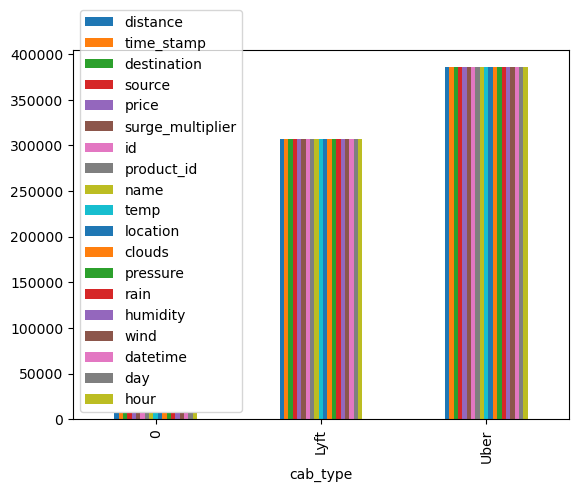

In [80]:
a.groupby('cab_type').count().plot.bar()

<Axes: xlabel='price'>

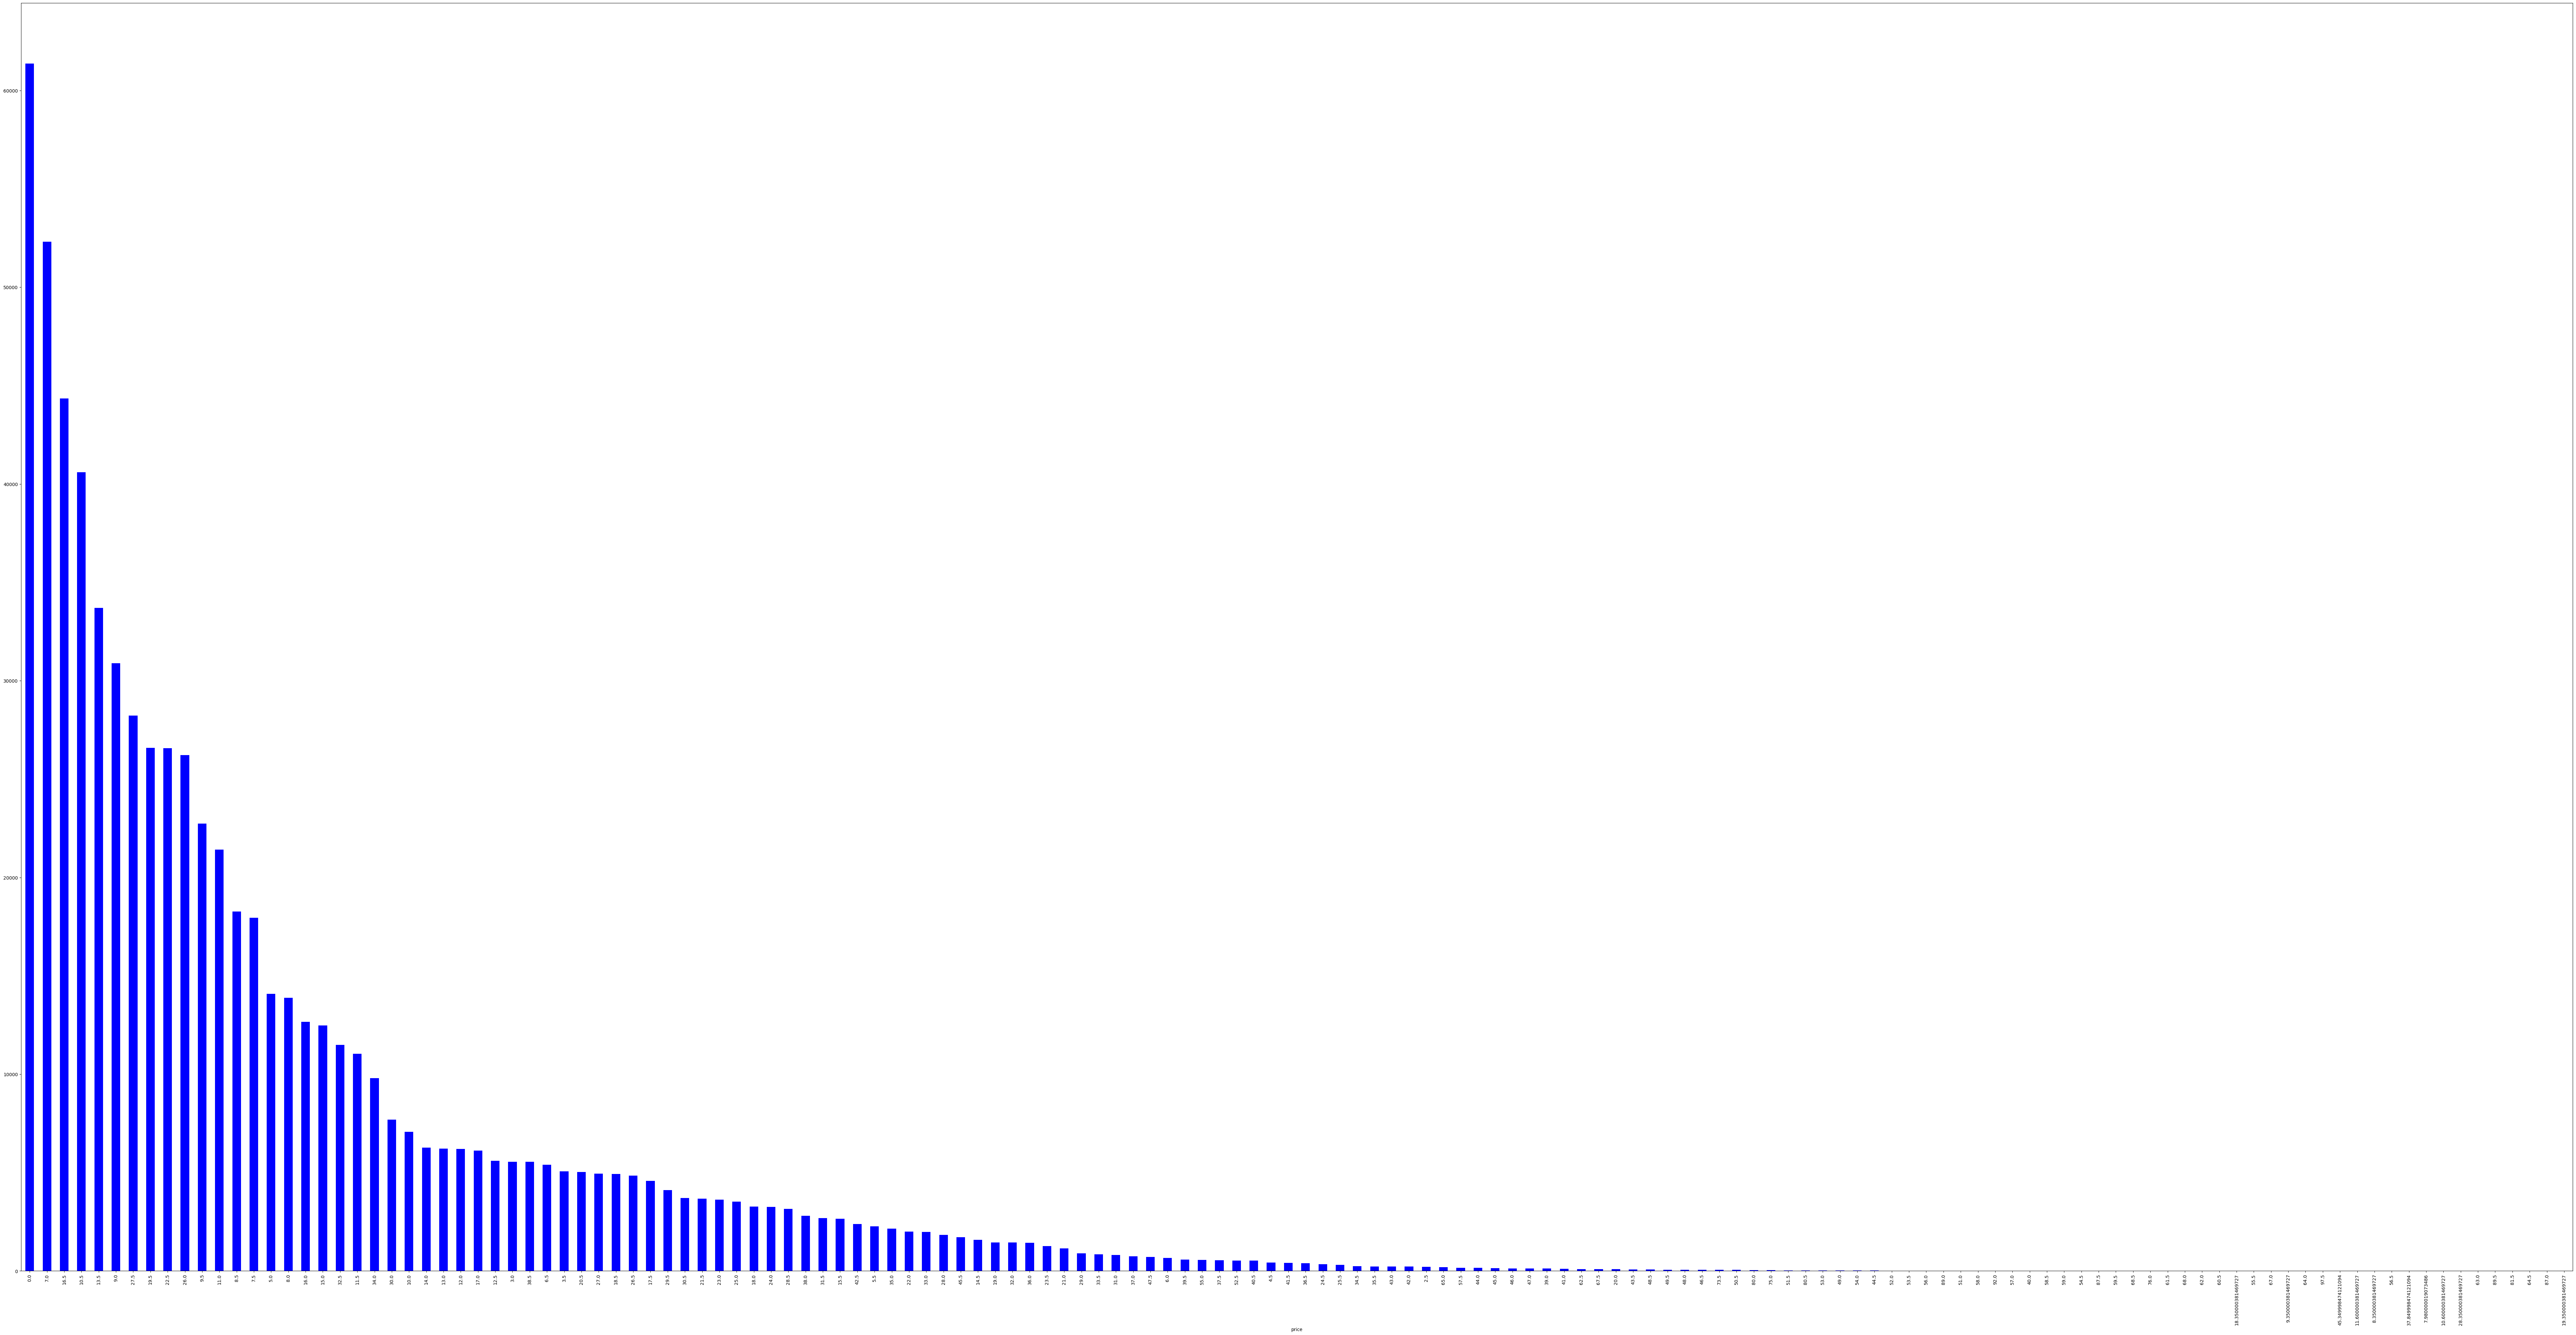

In [81]:
a['price'].value_counts().plot(kind='bar', figsize=(100,50), color='blue')

<Axes: xlabel='hour'>

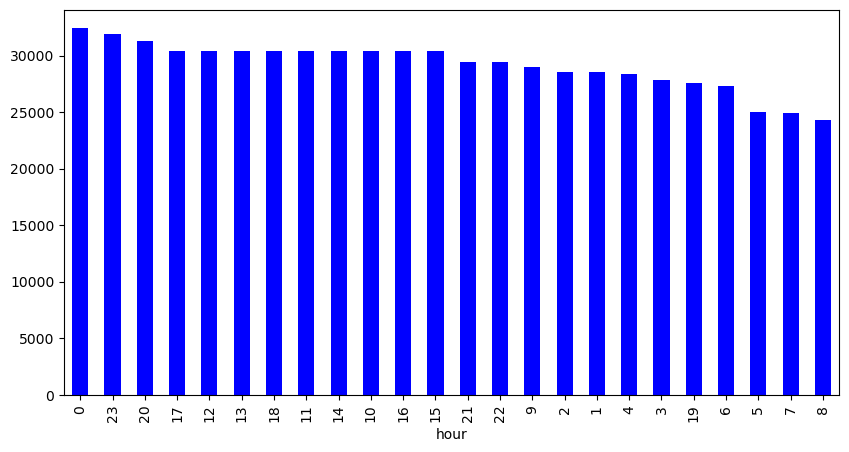

In [82]:
a['hour'].value_counts().plot(kind='bar', figsize=(10,5), color='blue')

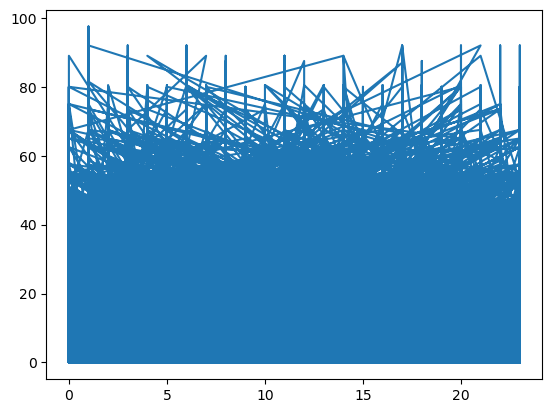

In [ ]:
x=a['hour'].values
y=a['price'].values
plt.plot(x,y)
plt.show()

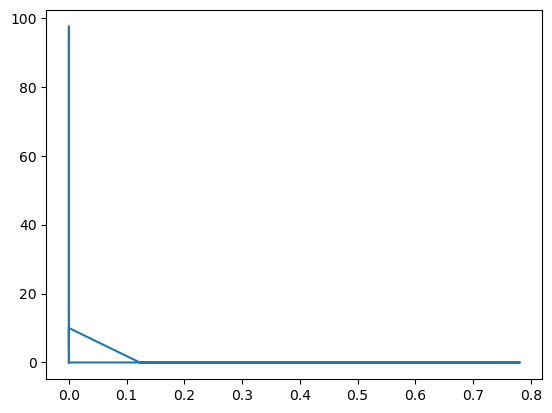

In [86]:
x=a['rain']
y=a['price']
plt.plot(x,y)
plt.show()

In [89]:
x1=a[['distance','temp','humidity','pressure','wind','rain','hour','day','surge_multiplier','clouds']]
y1=a['price']

In [92]:
from sklearn.model_selection import train_test_split
# 3. Split into training and testing sets
x_train,y_train, x_test, y_test = train_test_split(x1, y1, train_size=0.75, random_state=42)

In [94]:
linear = LinearRegression()
linear.fit(x_train, x_test)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [96]:
predictions = linear.predict(y_train)
predictions

array([32.54530352, 14.76134217, 16.81549863, ..., 11.82425174,
       11.86627787, 13.2205242 ], shape=(174837,))

In [97]:
df = pd.DataFrame({'Actual': y_test,'Predicted': predictions})
df

,Actual,Predicted
81607,42.5,32.545304
354,0.0,14.761342
471801,32.5,16.815499
407645,27.5,10.473420
474760,27.5,10.565939
...,...,...
538489,7.5,10.709920
579511,13.5,15.517604
5421,9.0,11.824252
279982,8.0,11.866278


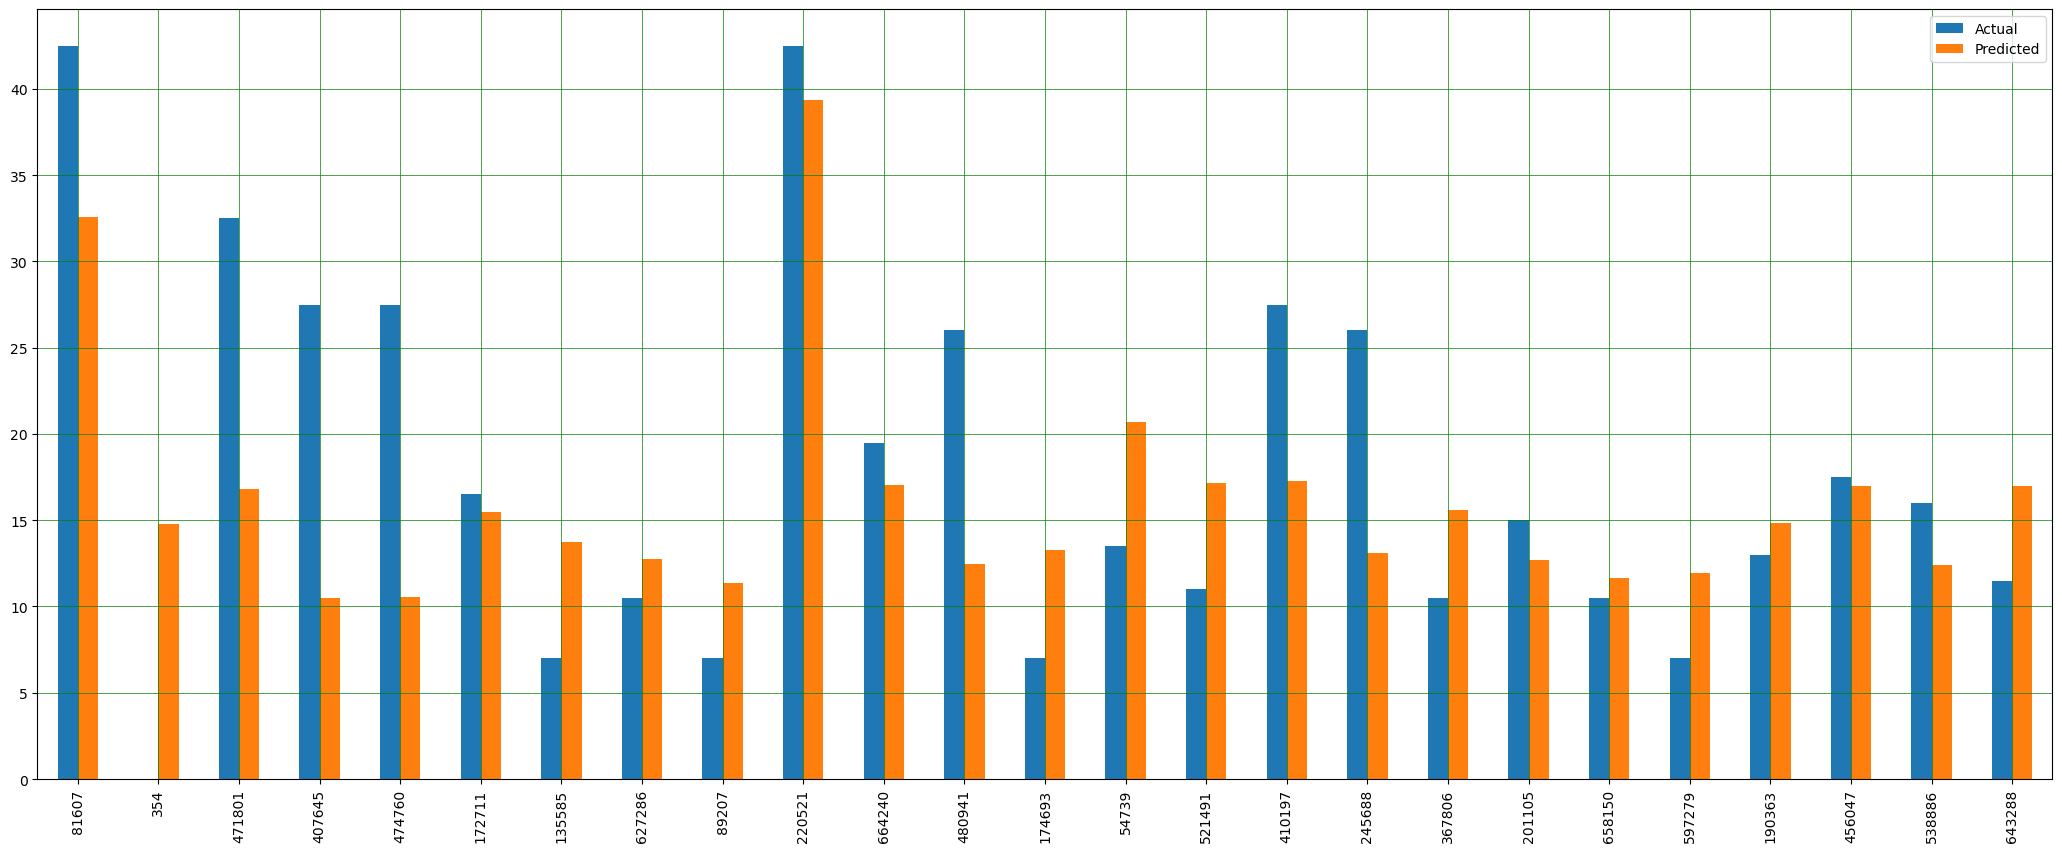

In [98]:
df1=df.head(25)
df1.plot(kind='bar',figsize=(26,10))
plt.grid(which='major', linestyle='-', linewidth='0.5', color='green')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')
plt.show()